In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

## Task 1 — Train the Network

100%|██████████| 26.4M/26.4M [02:49<00:00, 156kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 222kB/s]
100%|██████████| 4.42M/4.42M [00:14<00:00, 300kB/s] 
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.7MB/s]


FashionMLP(
  (main): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=64, bias=True)
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=64, out_features=10, bias=True)
  )
)
Epoch  1: Train Loss: 0.5878 | Val Acc: 85.34%
Epoch  2: Train Loss: 0.4018 | Val Acc: 86.73%
Epoch  3: Train Loss: 0.3664 | Val Acc: 86.62%
Epoch  4: Train Loss: 0.3415 | Val Acc: 87.23%
Epoch  5: Train Loss: 0.3198 | Val Acc: 88.29%
Epoch  6: Train Loss: 0.3037 | Val Acc: 

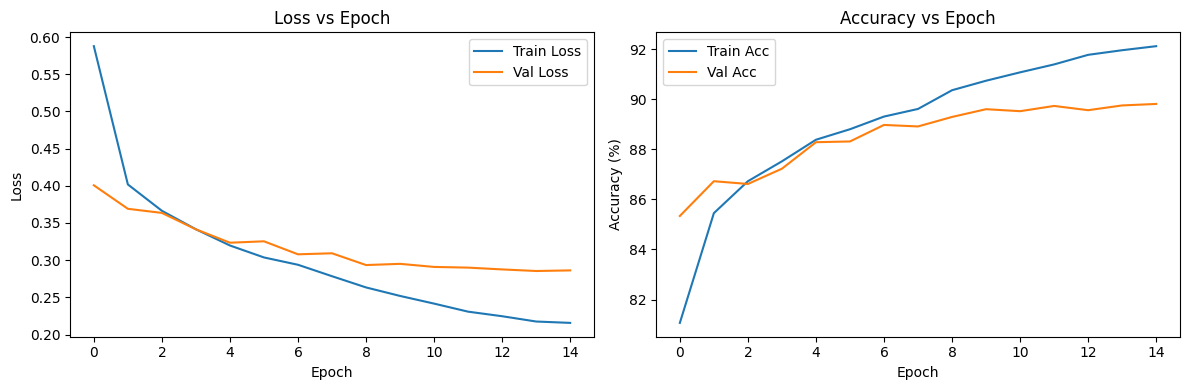

Best Validation Accuracy: 89.82% at Epoch 15


In [3]:
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.FashionMNIST(root="./data", train=True, download=True, transform=tf)
test_set = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tf)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(test_set, batch_size=256, shuffle=False)

class FashionMLP(nn.Module):
    def __init__(self):
        super(FashionMLP, self).__init__()
        self.main=nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
           
    def forward(self, x):
        return self.main(x)
    
model=FashionMLP().to(device)
print(model)

epochs=15
loss_function=nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

def train_and_validate(epochs, model, train_loader, val_loader, loss_function, optimizer, scheduler):
    train_losses=[]
    val_losses=[]
    train_accs=[]
    val_accs=[]

    for epoch in range(epochs):
        model.train()
        total_train_loss=0
        correct_train=0

        for X,y in train_loader:
            X,y=X.to(device), y.to(device)

            optimizer.zero_grad()
            pred=model(X)
            loss=loss_function(pred, y)
            loss.backward()
            optimizer.step()

            total_train_loss+=loss.item()
            correct_train += (pred.argmax(1) == y).type(torch.float).sum().item()

        scheduler.step()

        model.eval()

        total_val_loss = 0
        correct_val = 0

        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                total_val_loss += loss_function(pred, y).item()
                correct_val += (pred.argmax(1) == y).type(torch.float).sum().item()
        
        train_loss = total_train_loss / len(train_loader)
        val_loss = total_val_loss / len(val_loader)
        train_acc = (correct_train / len(train_loader.dataset)) * 100
        val_acc = (correct_val / len(val_loader.dataset)) * 100
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        print(f"Epoch {epoch+1:2d}: Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.2f}%")

    return train_losses, val_losses, train_accs, val_accs

t_loss, v_loss, t_acc, v_acc = train_and_validate(epochs, model, train_loader, val_loader, loss_function, optimizer, scheduler)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(t_loss, label="Train Loss")
ax1.plot(v_loss, label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss vs Epoch")
ax1.legend()

ax2.plot(t_acc, label="Train Acc")
ax2.plot(v_acc, label="Val Acc")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Accuracy vs Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

best_val_acc = max(v_acc)
best_epoch = v_acc.index(best_val_acc) + 1
print(f"Best Validation Accuracy: {best_val_acc:.2f}% at Epoch {best_epoch}")

The training and validation loss curves stay close together throughout the 15 epochs, indicating that the model is generalizing well and not overfitting thanks to the Dropout and BatchNorm layers. Both the loss and accuracy curves show that the model is still steadily improving at epoch 15, suggesting that a slightly higher accuracy might be possible with more training time. The best validation accuracy achieved was 89.82% at the final epoch, which aligns perfectly with the expected performance for this architecture.